# 🎵 Task 2: Prediksi Tahun Rilis Lagu
## End-to-End Deep Learning Regression Pipeline

---

**Nama**: Rahmanda Afebrio Yuris Soesatyo

**NIM**: 1103223024

---

### Deskripsi
Notebook ini membangun pipeline regresi end-to-end untuk memprediksi **tahun rilis lagu** berdasarkan fitur audio numerik.
Dataset `midterm-regresi-dataset.csv` memiliki kolom pertama sebagai target (tahun) dan kolom sisanya sebagai fitur audio.

Pipeline mencakup:
1. Eksplorasi dan Analisis Data (EDA)
2. Preprocessing & Feature Engineering
3. Penanganan Outlier (IQR)
4. Pembangunan Model Deep Learning (MLP Regresi)
5. Hyperparameter Tuning dengan **Optuna**
6. Evaluasi Model (MSE, RMSE, MAE, R²)
7. Interpretasi Model dengan **LIME**
8. Tracking Eksperimen dengan **MLFlow**

## 📦 0. Instalasi Library

In [1]:
%pip install lightgbm optuna mlflow lime tensorflow scikit-learn pandas numpy matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'lime' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'lime'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📚 1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import gc

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Hyperparameter Tuning
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Model Interpretasi
import lime
import lime.lime_tabular

# MLFlow Tracking
import mlflow
import mlflow.keras

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print('✅ Semua library berhasil diimport!')
print(f'TensorFlow version : {tf.__version__}')
print(f'Optuna version     : {optuna.__version__}')
print(f'MLFlow version     : {mlflow.__version__}')

c:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Semua library berhasil diimport!
TensorFlow version : 2.21.0
Optuna version     : 4.9.0
MLFlow version     : 3.14.0


## 📂 2. Load Dataset

Pastikan file `midterm-regresi-dataset.csv` ada di folder `Task2_SongYearRegression/`.

- Kolom **pertama** = target (tahun rilis lagu)
- Kolom sisanya = fitur audio numerik (feature_1, feature_2, ...)

In [3]:
# =====================================================
# KONFIGURASI PATH DATASET
# Ubah path di bawah jika file ada di lokasi lain
# =====================================================
DATASET_PATH = 'midterm-regresi-dataset.csv'

print('⏳ Memuat dataset...')
df_raw = pd.read_csv(DATASET_PATH, header=None)

# Beri nama kolom
n_features = df_raw.shape[1] - 1
col_names = ['year'] + [f'feature_{i+1}' for i in range(n_features)]
df_raw.columns = col_names

print(f'✅ Dataset berhasil dimuat!')
print(f'   Jumlah baris : {df_raw.shape[0]:,}')
print(f'   Jumlah kolom : {df_raw.shape[1]:,} (1 target + {n_features} fitur)')

⏳ Memuat dataset...
✅ Dataset berhasil dimuat!
   Jumlah baris : 515,345
   Jumlah kolom : 91 (1 target + 90 fitur)


## 🔍 3. Eksplorasi Data (EDA)

In [4]:
# Preview dataset
print('=== 5 Baris Pertama ===')
df_raw.head()

=== 5 Baris Pertama ===


,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [5]:
# Statistik deskriptif
print('=== Statistik Deskriptif ===')
df_raw.describe()

=== Statistik Deskriptif ===


,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Rentang tahun  : 1922 — 2011
Rata-rata tahun: 1998.4
Median tahun   : 2002
Std tahun      : 10.93


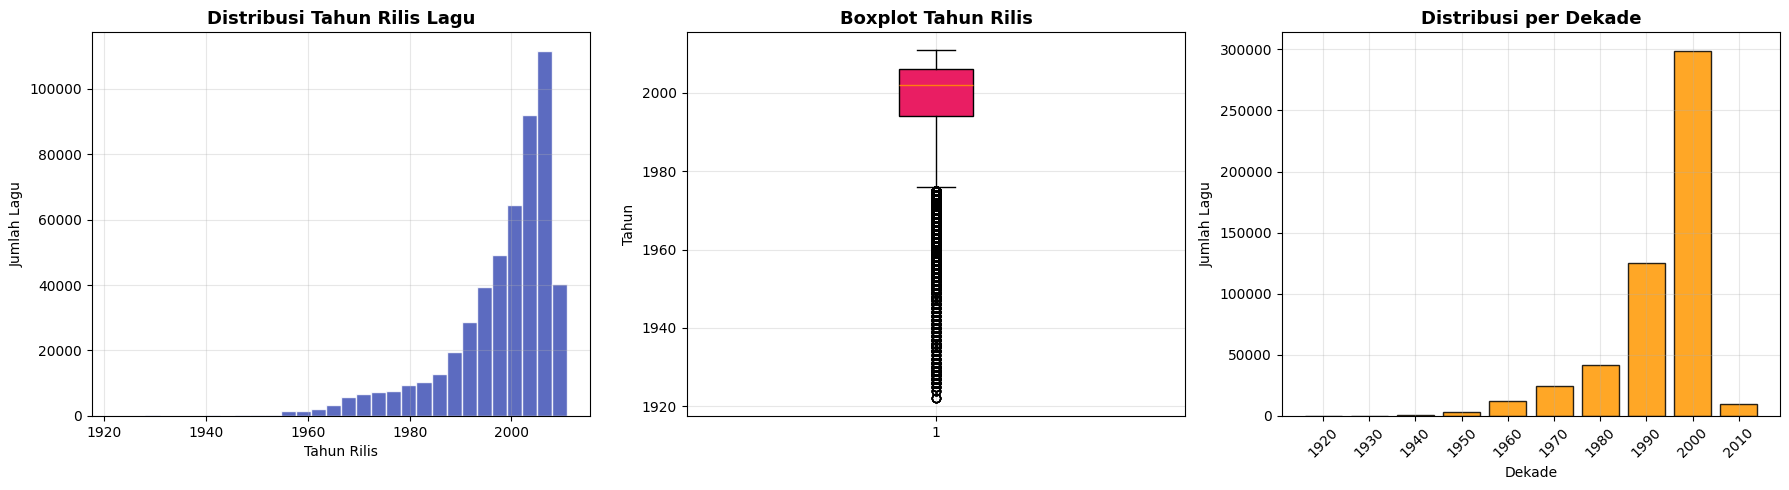

In [6]:
# =====================================================
# Analisis distribusi target: year
# =====================================================
print(f'Rentang tahun  : {df_raw["year"].min():.0f} — {df_raw["year"].max():.0f}')
print(f'Rata-rata tahun: {df_raw["year"].mean():.1f}')
print(f'Median tahun   : {df_raw["year"].median():.0f}')
print(f'Std tahun      : {df_raw["year"].std():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df_raw['year'], bins=30, color='#3F51B5', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Tahun Rilis')
axes[0].set_ylabel('Jumlah Lagu')
axes[0].set_title('Distribusi Tahun Rilis Lagu', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(df_raw['year'], vert=True, patch_artist=True,
               boxprops=dict(facecolor='#E91E63', color='black'))
axes[1].set_ylabel('Tahun')
axes[1].set_title('Boxplot Tahun Rilis', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Per dekade
df_raw['decade'] = (df_raw['year'] // 10) * 10
decade_counts = df_raw['decade'].value_counts().sort_index()
axes[2].bar(decade_counts.index.astype(str), decade_counts.values,
            color='#FF9800', edgecolor='black', alpha=0.85)
axes[2].set_xlabel('Dekade')
axes[2].set_ylabel('Jumlah Lagu')
axes[2].set_title('Distribusi per Dekade', fontsize=13, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_distribusi_tahun.png', dpi=100, bbox_inches='tight')
plt.show()

df_raw = df_raw.drop(columns=['decade'])

In [7]:
# =====================================================
# Cek Missing Values
# =====================================================
total_missing = df_raw.isnull().sum().sum()
print(f'Total missing values: {total_missing}')
if total_missing == 0:
    print('✅ Dataset bersih — tidak ada missing values!')
else:
    missing = df_raw.isnull().sum()[df_raw.isnull().sum() > 0]
    print(missing)

Total missing values: 0
✅ Dataset bersih — tidak ada missing values!


Top 15 fitur berkorelasi dengan tahun rilis:
feature_1     0.225374
feature_6     0.187443
feature_3     0.139541
feature_63    0.126348
feature_40    0.123974
feature_7     0.110460
feature_67    0.102841
feature_46    0.101324
feature_36    0.101007
feature_69    0.099484
feature_12    0.097164
feature_57    0.096973
feature_47    0.096088
feature_59    0.092747
feature_33    0.091186
Name: year, dtype: float64


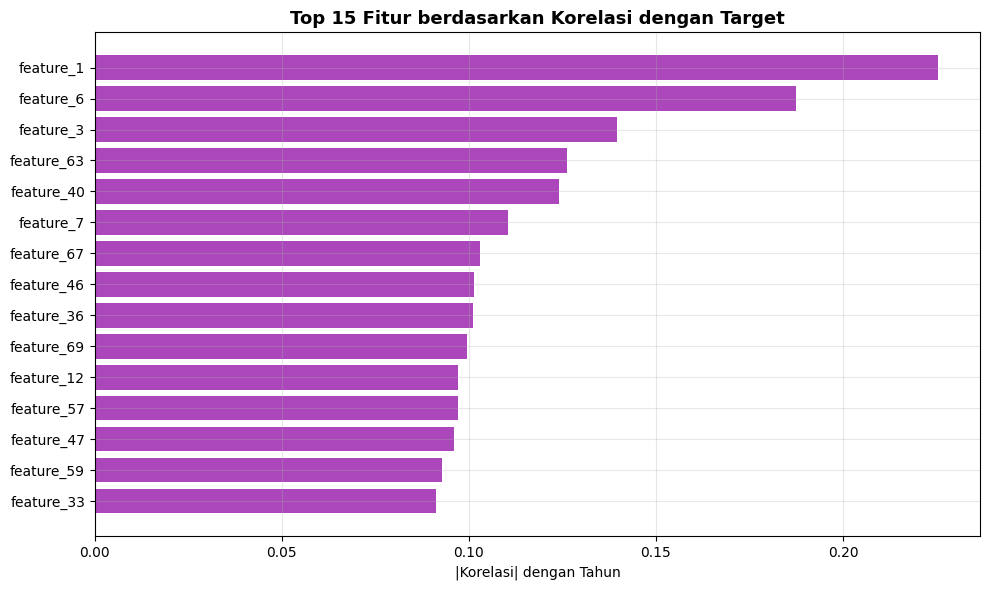

In [8]:
# =====================================================
# Korelasi fitur dengan target (year)
# =====================================================
feature_cols = [f'feature_{i+1}' for i in range(n_features)]
corr_vals = df_raw[feature_cols + ['year']].corr()['year'].drop('year').abs()
top_corr = corr_vals.sort_values(ascending=False).head(15)

print('Top 15 fitur berkorelasi dengan tahun rilis:')
print(top_corr)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_corr.index[::-1], top_corr.values[::-1], color='#9C27B0', alpha=0.85)
ax.set_xlabel('|Korelasi| dengan Tahun')
ax.set_title('Top 15 Fitur berdasarkan Korelasi dengan Target', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_korelasi_fitur.png', dpi=100, bbox_inches='tight')
plt.show()

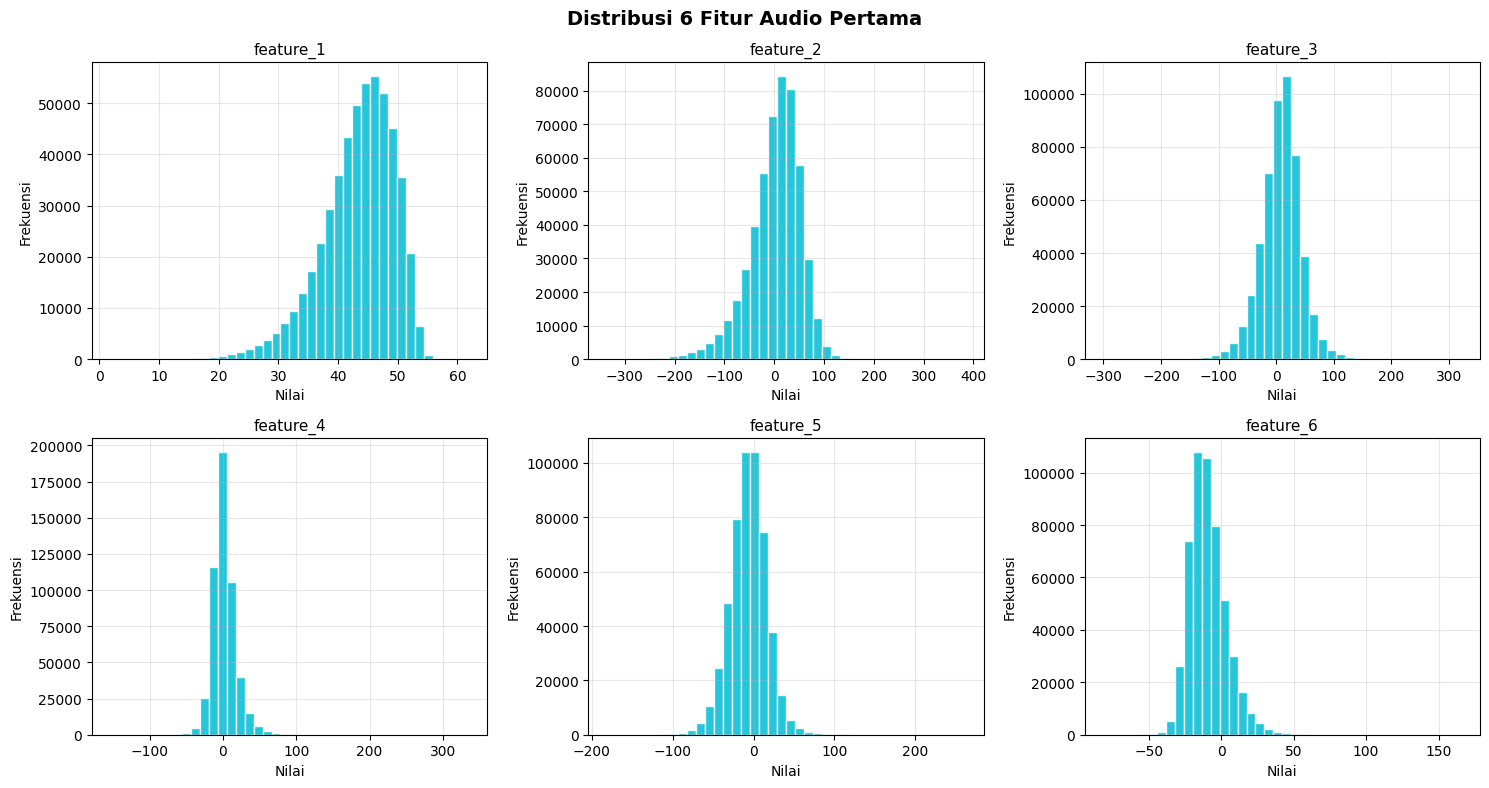

In [9]:
# =====================================================
# Distribusi 6 fitur audio pertama
# =====================================================
sample_feats = feature_cols[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, feat in enumerate(sample_feats):
    axes[i].hist(df_raw[feat], bins=40, color='#00BCD4', edgecolor='white', alpha=0.85)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribusi 6 Fitur Audio Pertama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_distribusi_fitur.png', dpi=100, bbox_inches='tight')
plt.show()

## 🛠️ 4. Preprocessing Data

In [10]:
# =====================================================
# 4.1 Pisahkan fitur dan target
# =====================================================
X = df_raw[feature_cols].values
y = df_raw['year'].values

print(f'Shape X (fitur) : {X.shape}')
print(f'Shape y (target): {y.shape}')
print(f'Range target    : [{y.min():.0f}, {y.max():.0f}]')

Shape X (fitur) : (515345, 90)
Shape y (target): (515345,)
Range target    : [1922, 2011]


In [11]:
# =====================================================
# 4.2 Imputasi missing values (jika ada)
# =====================================================
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)
print(f'✅ Imputasi selesai. Sisa missing: {np.isnan(X).sum()}')

✅ Imputasi selesai. Sisa missing: 0


In [12]:
# =====================================================
# 4.3 Penanganan Outlier dengan IQR Clipping
# Clip nilai ekstrem ke batas IQR agar tidak merusak
# distribusi — lebih aman dari menghapus baris
# =====================================================
X_df = pd.DataFrame(X, columns=feature_cols)

outlier_counts = {}
for col in feature_cols:
    Q1, Q3 = X_df[col].quantile(0.25), X_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((X_df[col] < lower) | (X_df[col] > upper)).sum()
    outlier_counts[col] = n_out
    X_df[col] = X_df[col].clip(lower, upper)

top_outlier = sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)[:5]
print('Top 5 fitur dengan outlier terbanyak (sebelum clipping):')
for feat, cnt in top_outlier:
    print(f'  {feat}: {cnt:,}')

X = X_df.values
print(f'\n✅ IQR clipping selesai. Shape X: {X.shape}')

Top 5 fitur dengan outlier terbanyak (sebelum clipping):
  feature_68: 46,753
  feature_37: 46,192
  feature_27: 45,593
  feature_46: 42,450
  feature_25: 41,997

✅ IQR clipping selesai. Shape X: (515345, 90)


In [13]:
# =====================================================
# 4.4 Feature Engineering
# Tambah fitur kuadrat untuk top-5 fitur paling
# berkorelasi dengan target — bantu model menangkap
# hubungan non-linear
# =====================================================
corr_abs = np.abs(np.corrcoef(X.T, y)[-1, :-1])
top5_idx = np.argsort(corr_abs)[-5:][::-1]
top5_names = [feature_cols[i] for i in top5_idx]

X_df = pd.DataFrame(X, columns=feature_cols)
for feat in top5_names:
    X_df[f'{feat}_sq'] = X_df[feat] ** 2

X = X_df.values
feature_names_eng = list(X_df.columns)

print(f'✅ Feature engineering selesai.')
print(f'   Fitur asli       : {len(feature_cols)}')
print(f'   Fitur baru (sq)  : 5')
print(f'   Total fitur akhir: {X.shape[1]}')
print(f'   Fitur yang di-sq : {top5_names}')

✅ Feature engineering selesai.
   Fitur asli       : 90
   Fitur baru (sq)  : 5
   Total fitur akhir: 95
   Fitur yang di-sq : ['feature_1', 'feature_6', 'feature_3', 'feature_63', 'feature_40']


In [14]:
# =====================================================
# 4.5 Split data: Train 70% / Val 15% / Test 15%
# =====================================================
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42)

print(f'Train set : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Val set   : {X_val.shape[0]:,} baris ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test set  : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X)*100:.1f}%)')

Train set : 372,336 baris (72.2%)
Val set   : 65,707 baris (12.8%)
Test set  : 77,302 baris (15.0%)


In [15]:
# =====================================================
# 4.6 Normalisasi Fitur & Target
# Scaler di-fit HANYA pada train set untuk mencegah
# data leakage
# =====================================================
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

# Normalisasi target
y_mean = y_train.mean()
y_std  = y_train.std()
y_train_norm = (y_train - y_mean) / y_std
y_val_norm   = (y_val   - y_mean) / y_std

print('✅ Normalisasi selesai!')
print(f'   Mean target (train): {y_mean:.2f}')
print(f'   Std target (train) : {y_std:.2f}')

✅ Normalisasi selesai!
   Mean target (train): 1998.39
   Std target (train) : 10.94


## 🧠 5. Pembangunan Model Deep Learning (Regresi)

Arsitektur: **MLP Regresi** dengan:
- Hidden layer: ReLU + Batch Normalization + Dropout
- Output layer: aktivasi **Linear** (regresi)
- Loss: **Huber Loss** (robust terhadap outlier, lebih baik dari MSE murni)

In [16]:
def build_regression_model(input_dim, n_layers=3, units=128,
                           dropout_rate=0.3, learning_rate=1e-3):
    """
    Membangun model MLP untuk regresi.

    Parameter:
    - input_dim    : jumlah fitur input
    - n_layers     : jumlah hidden layer
    - units        : ukuran neuron layer pertama (berkurang tiap layer)
    - dropout_rate : dropout rate untuk regularisasi
    - learning_rate: learning rate Adam
    """
    inputs = keras.Input(shape=(input_dim,))
    x = inputs

    for i in range(n_layers):
        layer_units = max(32, units // (2 ** i))  # pyramid: makin kecil tiap layer
        x = layers.Dense(layer_units, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(1, activation='linear')(x)  # output linear untuk regresi

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='huber',
        metrics=['mae', 'mse']
    )
    return model

# Demo arsitektur
model_demo = build_regression_model(X_train_scaled.shape[1])
model_demo.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 95)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,553 (92.00 KB)

 Trainable params: 23,105 (90.25 KB)

 Non-trainable params: 448 (1.75 KB)

## ⚙️ 6. Hyperparameter Tuning dengan Optuna

Optuna menggunakan **TPE (Tree-structured Parzen Estimator)** — algoritma Bayesian yang cerdas memilih kombinasi hyperparameter berikutnya berdasarkan hasil trial sebelumnya.

In [17]:
INPUT_DIM = X_train_scaled.shape[1]

def objective_regression(trial):
    """
    Fungsi objektif Optuna untuk regresi.
    Mengembalikan MAE (skala tahun asli) pada validation set.
    Semakin kecil semakin baik.
    """
    # Bersihkan memori antar trial
    tf.keras.backend.clear_session()
    gc.collect()

    # Ruang pencarian hyperparameter
    n_layers     = trial.suggest_int('n_layers', 2, 4)
    units        = trial.suggest_categorical('units', [64, 128, 256])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    lr           = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [512, 1024])

    model = build_regression_model(
        input_dim=INPUT_DIM,
        n_layers=n_layers,
        units=units,
        dropout_rate=dropout_rate,
        learning_rate=lr
    )

    early_stop = callbacks.EarlyStopping(
        monitor='val_mae', patience=5, restore_best_weights=True, mode='min'
    )

    history = model.fit(
        X_train_scaled, y_train_norm,
        validation_data=(X_val_scaled, y_val_norm),
        epochs=30,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # Konversi MAE ke skala tahun asli
    best_mae = min(history.history['val_mae']) * y_std

    tf.keras.backend.clear_session()
    gc.collect()
    return best_mae

print('⏳ Memulai Optuna hyperparameter tuning...')
print('   (Setiap trial ±1-2 menit, total ±15-20 menit)')

study_reg = optuna.create_study(
    direction='minimize',
    study_name='song_year_regression',
    sampler=TPESampler(seed=42)
)
study_reg.optimize(
    objective_regression,
    n_trials=10,
    catch=(Exception,),
    show_progress_bar=True
)

print(f'\n✅ Optuna selesai!')
print(f'   Best MAE (tahun): {study_reg.best_value:.2f}')
print(f'   Best params     : {study_reg.best_params}')

⏳ Memulai Optuna hyperparameter tuning...
   (Setiap trial ±1-2 menit, total ±15-20 menit)


  0%|          | 0/10 [00:00<?, ?it/s]

Best trial: 5. Best value: 5.66538: 100%|██████████| 10/10 [11:44<00:00, 70.42s/it]


✅ Optuna selesai!
   Best MAE (tahun): 5.67
   Best params     : {'n_layers': 2, 'units': 256, 'dropout_rate': 0.20351199264000677, 'learning_rate': 0.0021137059440645744, 'batch_size': 1024}


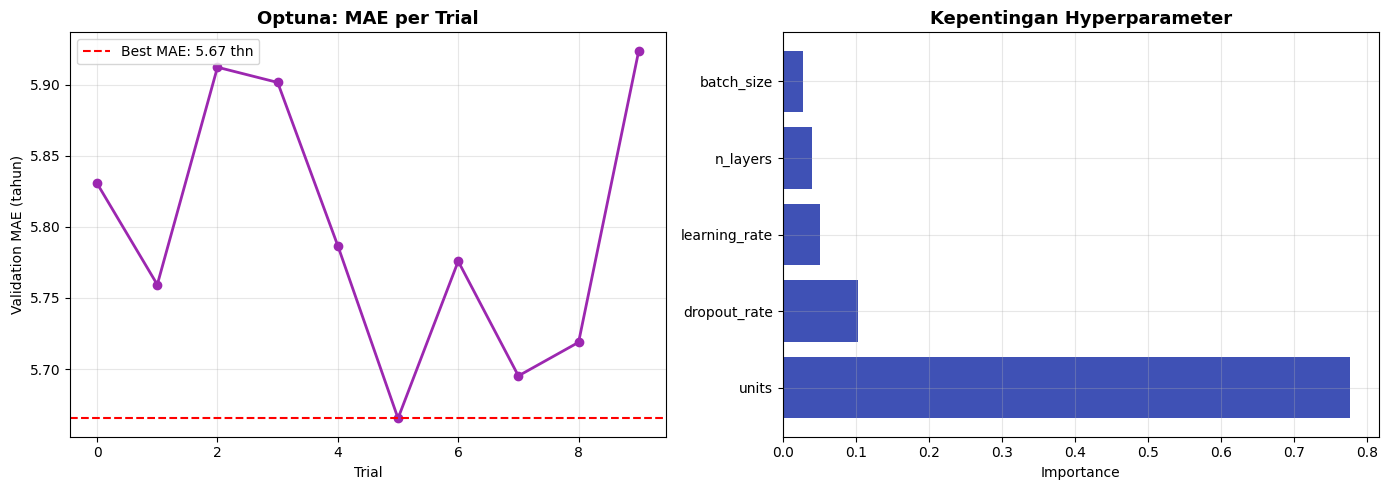

In [18]:
# =====================================================
# Visualisasi hasil Optuna
# =====================================================
valid_trials = [t for t in study_reg.trials if t.value is not None]
trial_values = [t.value for t in valid_trials]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(trial_values, marker='o', color='#9C27B0', linewidth=2)
axes[0].axhline(y=study_reg.best_value, color='red', linestyle='--',
               label=f'Best MAE: {study_reg.best_value:.2f} thn')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Validation MAE (tahun)')
axes[0].set_title('Optuna: MAE per Trial', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

try:
    importance = optuna.importance.get_param_importances(study_reg)
    axes[1].barh(list(importance.keys()), list(importance.values()), color='#3F51B5')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Kepentingan Hyperparameter', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
except:
    axes[1].text(0.5, 0.5, 'Tidak cukup trial\nuntuk hitung importance',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('plot_optuna_results.png', dpi=100, bbox_inches='tight')
plt.show()

## 🏋️ 7. Training Model Final + MLFlow Tracking

In [19]:
# =====================================================
# Setup MLFlow — gunakan SQLite (file store deprecated)
# =====================================================
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('Song_Year_Regression_Task2')

best_params = study_reg.best_params
print('🚀 Memulai training model final...')
print(f'Hyperparameter terbaik: {best_params}')

2026/06/19 23:54:19 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 23:54:19 INFO mlflow.store.db.utils: Updating database tables
2026/06/19 23:54:21 INFO mlflow.tracking.fluent: Experiment with name 'Song_Year_Regression_Task2' does not exist. Creating a new experiment.


🚀 Memulai training model final...
Hyperparameter terbaik: {'n_layers': 2, 'units': 256, 'dropout_rate': 0.20351199264000677, 'learning_rate': 0.0021137059440645744, 'batch_size': 1024}


In [20]:
tf.keras.backend.clear_session()
gc.collect()

with mlflow.start_run(run_name='best_model_song_year') as run:

    # Log hyperparameter
    mlflow.log_params(best_params)
    mlflow.log_param('loss_function', 'huber')
    mlflow.log_param('scaler', 'StandardScaler')
    mlflow.log_param('target_normalized', True)
    mlflow.log_param('n_features_original', len(feature_cols))
    mlflow.log_param('n_features_engineered', X_train_scaled.shape[1])
    mlflow.log_param('feature_engineering', 'polynomial_sq_top5')

    # Build model final
    final_model = build_regression_model(
        input_dim=X_train_scaled.shape[1],
        n_layers=best_params.get('n_layers', 3),
        units=best_params.get('units', 128),
        dropout_rate=best_params.get('dropout_rate', 0.3),
        learning_rate=best_params.get('learning_rate', 1e-3)
    )

    batch_size = best_params.get('batch_size', 512)

    # Callbacks
    early_stop = callbacks.EarlyStopping(
        monitor='val_mae', patience=8, restore_best_weights=True, mode='min'
    )
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
    )

    # Training
    history = final_model.fit(
        X_train_scaled, y_train_norm,
        validation_data=(X_val_scaled, y_val_norm),
        epochs=80,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # Prediksi & inverse normalize ke skala tahun asli
    y_pred_norm = final_model.predict(X_test_scaled, verbose=0).ravel()
    y_pred      = y_pred_norm * y_std + y_mean

    # Hitung metrik regresi
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f'\n📊 Hasil Evaluasi pada Test Set:')
    print(f'   MSE  : {mse:.4f}')
    print(f'   RMSE : {rmse:.4f} tahun')
    print(f'   MAE  : {mae:.4f} tahun')
    print(f'   R²   : {r2:.4f}')

    # Log metrik
    mlflow.log_metric('test_mse',  mse)
    mlflow.log_metric('test_rmse', rmse)
    mlflow.log_metric('test_mae',  mae)
    mlflow.log_metric('test_r2',   r2)

    # Log training history per epoch
    for epoch, (loss, mae_e) in enumerate(zip(
        history.history['loss'], history.history['mae']
    )):
        mlflow.log_metric('train_loss', loss, step=epoch)
        mlflow.log_metric('train_mae_year', mae_e * y_std, step=epoch)

    # Simpan model
    mlflow.keras.log_model(final_model, 'song_year_model')

    run_id = run.info.run_id

print(f'\n✅ MLFlow tracking selesai! Run ID: {run_id}')
print('Jalankan: mlflow ui --backend-store-uri sqlite:///mlflow.db')

Epoch 1/80
364/364 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.3124 - mae: 0.6259 - mse: 0.8369 - val_loss: 0.2557 - val_mae: 0.5459 - val_mse: 0.6899 - learning_rate: 0.0021
Epoch 2/80
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2579 - mae: 0.5501 - mse: 0.6849 - val_loss: 0.2502 - val_mae: 0.5346 - val_mse: 0.6754 - learning_rate: 0.0021
Epoch 3/80
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2531 - mae: 0.5426 - mse: 0.6713 - val_loss: 0.2471 - val_mae: 0.5309 - val_mse: 0.6642 - learning_rate: 0.0021
Epoch 4/80
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2499 - mae: 0.5376 - mse: 0.6629 - val_loss: 0.2454 - val_mae: 0.5273 - val_mse: 0.6609 - learning_rate: 0.0021
Epoch 5/80
364/364 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.2477 - mae: 0.5343 - mse: 0.6570 - val_loss: 0.2438 - val_mae: 0.5273 - val_mse: 0.6536 - learning_rate: 0.0021
Epoch 6/80
364/364 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2456 - mae: 0.5312 - mse: 0.6510 - val_loss: 0.2433 - val_mae: 0.526

2026/06/19 23:55:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 23:55:54 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.



✅ MLFlow tracking selesai! Run ID: 14419e40ef874dda97e958e9d05a6eb0
Jalankan: mlflow ui --backend-store-uri sqlite:///mlflow.db


## 📊 8. Evaluasi Model

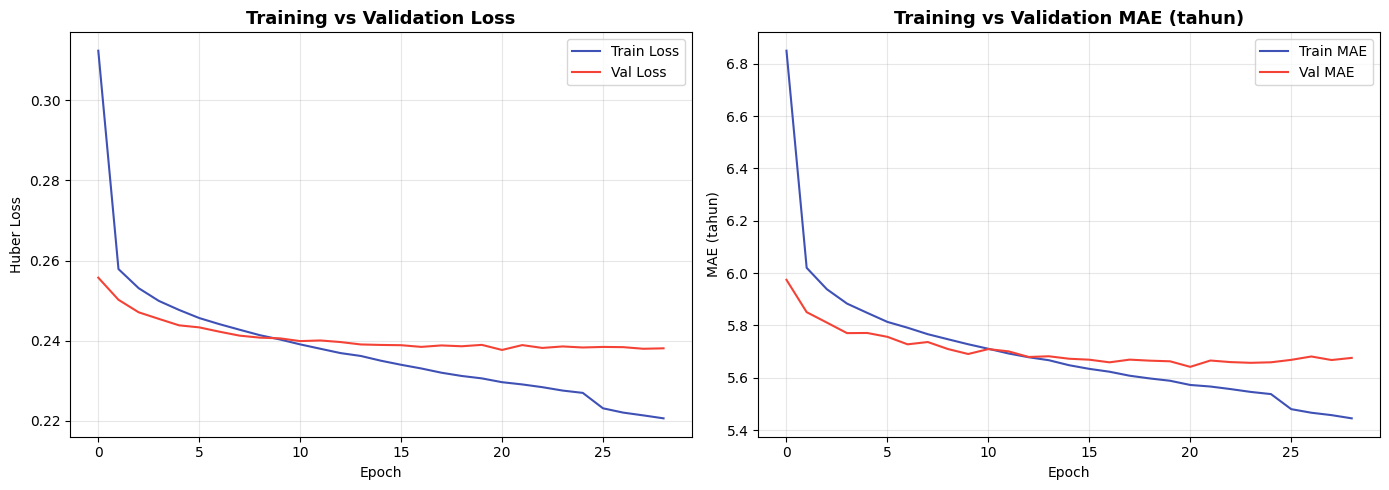

In [21]:
# =====================================================
# 8.1 Training History
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color='#3F51B5')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#F44336')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

train_mae_yr = [v * y_std for v in history.history['mae']]
val_mae_yr   = [v * y_std for v in history.history['val_mae']]
axes[1].plot(train_mae_yr, label='Train MAE', color='#3F51B5')
axes[1].plot(val_mae_yr,   label='Val MAE',   color='#F44336')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (tahun)')
axes[1].set_title('Training vs Validation MAE (tahun)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_training_history.png', dpi=100, bbox_inches='tight')
plt.show()

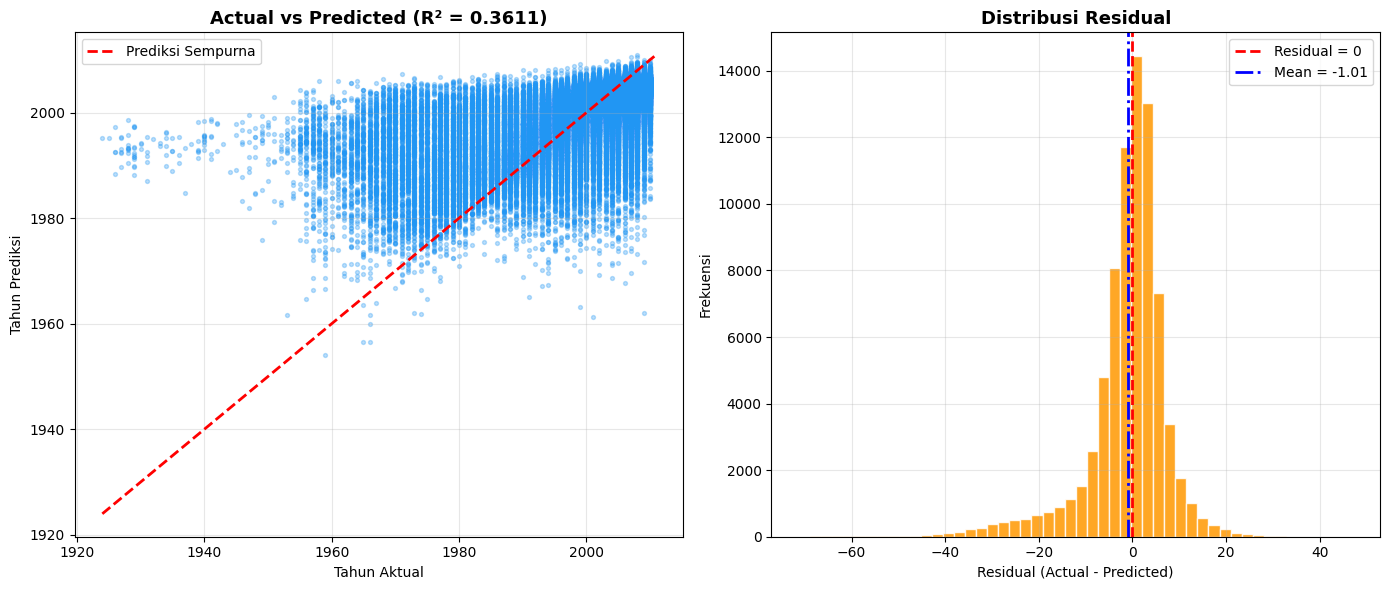

Statistik Residual:
  Mean  : -1.0100
  Std   : 8.6286
  Min   : -71.2230
  Max   : 46.9883


In [22]:
# =====================================================
# 8.2 Actual vs Predicted + Residual
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='#2196F3')
min_v, max_v = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Tahun Aktual')
axes[0].set_ylabel('Tahun Prediksi')
axes[0].set_title(f'Actual vs Predicted (R² = {r2:.4f})', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram Residual
residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, color='#FF9800', edgecolor='white', alpha=0.85)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2, label='Residual = 0')
axes[1].axvline(x=residuals.mean(), color='blue', linestyle='-.', lw=2,
               label=f'Mean = {residuals.mean():.2f}')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Statistik Residual:')
print(f'  Mean  : {residuals.mean():.4f}')
print(f'  Std   : {residuals.std():.4f}')
print(f'  Min   : {residuals.min():.4f}')
print(f'  Max   : {residuals.max():.4f}')

In [23]:
# =====================================================
# 8.3 Ringkasan Metrik Evaluasi
# =====================================================
metrics_df = pd.DataFrame({
    'Metrik'     : ['MSE', 'RMSE', 'MAE', 'R²'],
    'Nilai'      : [round(mse,4), round(rmse,4), round(mae,4), round(r2,4)],
    'Satuan'     : ['tahun²', 'tahun', 'tahun', '-'],
    'Keterangan' : [
        'Mean Squared Error — sensitif terhadap outlier',
        'Root MSE — interpretable dalam satuan tahun',
        'Mean Absolute Error — rata-rata selisih absolut',
        'Koefisien determinasi (1.0 = sempurna)'
    ]
})
print('=== Metrik Evaluasi Model Regresi ===')
print(metrics_df.to_string(index=False))

=== Metrik Evaluasi Model Regresi ===
Metrik   Nilai Satuan                                      Keterangan
   MSE 75.4729 tahun²  Mean Squared Error — sensitif terhadap outlier
  RMSE  8.6875  tahun     Root MSE — interpretable dalam satuan tahun
   MAE  5.6197  tahun Mean Absolute Error — rata-rata selisih absolut
    R²  0.3611      -          Koefisien determinasi (1.0 = sempurna)


## 🔬 9. Interpretasi Model dengan LIME

**LIME (Local Interpretable Model-agnostic Explanations)** menjelaskan prediksi model untuk sampel individual dengan membuat model linear lokal di sekitar titik tersebut.

- Warna **hijau** = fitur yang **mendorong naik** prediksi (tahun lebih baru)
- Warna **merah** = fitur yang **mendorong turun** prediksi (tahun lebih lama)

In [24]:
# =====================================================
# 9.1 Setup LIME Explainer
# =====================================================
def predict_fn(X_input):
    """Wrapper prediksi untuk LIME — kembalikan skala tahun asli"""
    pred_norm = final_model.predict(X_input, verbose=0).ravel()
    return pred_norm * y_std + y_mean

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=feature_names_eng,
    mode='regression',
    random_state=42
)

print('✅ LIME Explainer siap!')

✅ LIME Explainer siap!


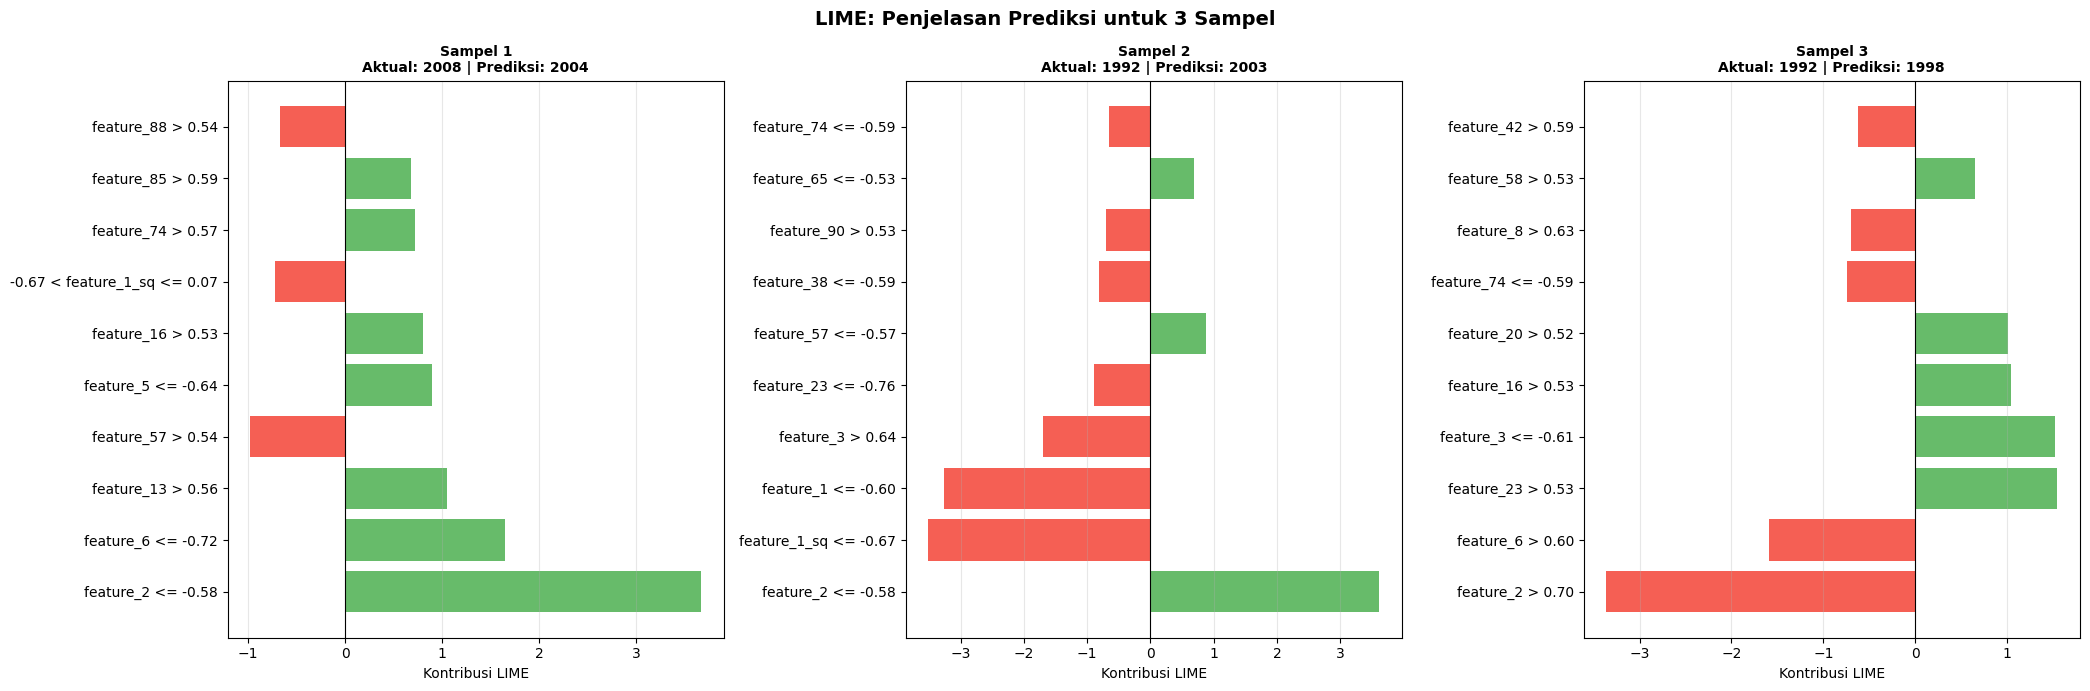

✅ LIME explanations selesai!


In [25]:
# =====================================================
# 9.2 Penjelasan LIME untuk 3 sampel berbeda
# =====================================================
sample_indices = [0, len(X_test_scaled)//2, -1]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for plot_idx, sample_idx in enumerate(sample_indices):
    sample      = X_test_scaled[sample_idx]
    actual_year = y_test[sample_idx]
    pred_year   = y_pred[sample_idx]

    exp = explainer.explain_instance(
        data_row=sample, predict_fn=predict_fn, num_features=10
    )

    lime_vals = exp.as_list()
    labels = [lv[0] for lv in lime_vals]
    values = [lv[1] for lv in lime_vals]
    colors = ['#4CAF50' if v > 0 else '#F44336' for v in values]

    axes[plot_idx].barh(labels, values, color=colors, alpha=0.85)
    axes[plot_idx].axvline(x=0, color='black', linewidth=0.8)
    axes[plot_idx].set_title(
        f'Sampel {plot_idx+1}\nAktual: {actual_year:.0f} | Prediksi: {pred_year:.0f}',
        fontsize=10, fontweight='bold'
    )
    axes[plot_idx].set_xlabel('Kontribusi LIME')
    axes[plot_idx].grid(True, alpha=0.3, axis='x')

plt.suptitle('LIME: Penjelasan Prediksi untuk 3 Sampel',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_lime_explanations.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ LIME explanations selesai!')

⏳ Menghitung global importance (50 sampel)...


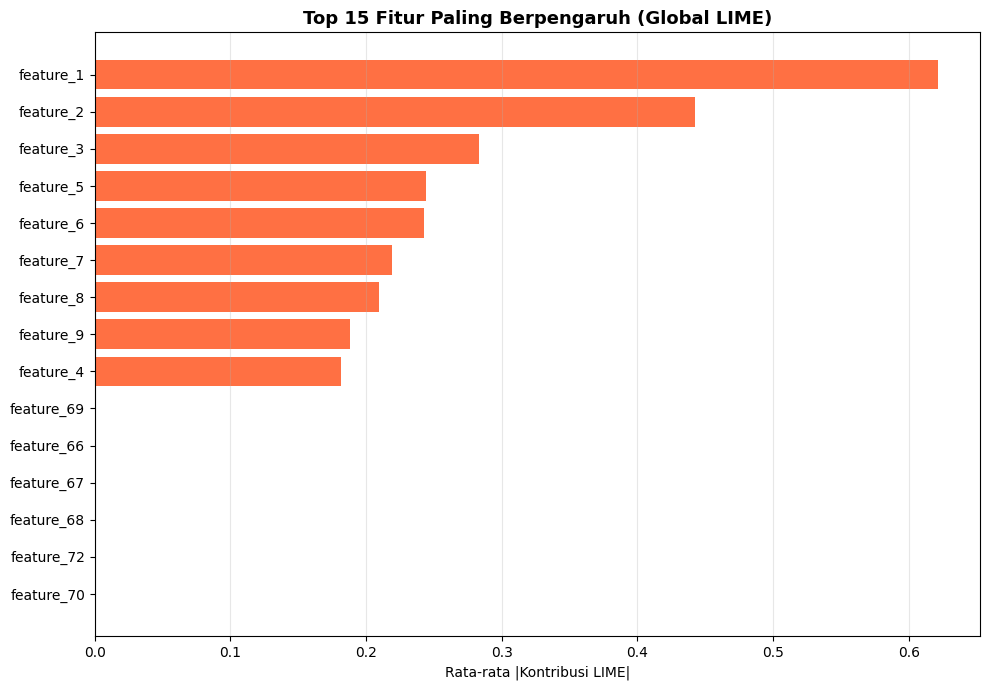


Fitur paling berpengaruh: feature_1 dan feature_2
✅ Semua plot di-log ke MLFlow!


In [26]:
# =====================================================
# 9.3 Global Feature Importance via LIME
# Rata-rata kontribusi absolut dari 50 sampel random
# =====================================================
print('⏳ Menghitung global importance (50 sampel)...')

np.random.seed(42)
n_lime = min(50, len(X_test_scaled))
lime_idxs = np.random.choice(len(X_test_scaled), n_lime, replace=False)

feat_importance = {feat: [] for feat in feature_names_eng}

for idx in lime_idxs:
    exp = explainer.explain_instance(
        data_row=X_test_scaled[idx],
        predict_fn=predict_fn,
        num_features=len(feature_names_eng)
    )
    for feat_cond, val in exp.as_list():
        for fn in feature_names_eng:
            if fn in feat_cond:
                feat_importance[fn].append(abs(val))
                break

mean_imp = pd.Series({k: np.mean(v) if v else 0 for k, v in feat_importance.items()})
mean_imp = mean_imp.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top15 = mean_imp.head(15)
ax.barh(top15.index[::-1], top15.values[::-1], color='#FF5722', alpha=0.85)
ax.set_xlabel('Rata-rata |Kontribusi LIME|')
ax.set_title('Top 15 Fitur Paling Berpengaruh (Global LIME)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('plot_lime_global.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nFitur paling berpengaruh: {mean_imp.index[0]} dan {mean_imp.index[1]}')

# Log plot ke MLFlow
with mlflow.start_run(run_id=run_id):
    for f in ['plot_lime_explanations.png', 'plot_lime_global.png',
              'plot_actual_vs_predicted.png', 'plot_training_history.png',
              'plot_optuna_results.png', 'plot_korelasi_fitur.png']:
        if os.path.exists(f):
            mlflow.log_artifact(f)
print('✅ Semua plot di-log ke MLFlow!')

## 🔚 10. Kesimpulan

### Ringkasan Pipeline

| Tahap | Metode |
|-------|--------|
| Preprocessing | Median Imputation, IQR Clipping |
| Feature Engineering | Polynomial (kuadrat) top-5 fitur |
| Normalisasi | StandardScaler (fitur), Z-normalization (target) |
| Model | MLP Regresi + BatchNorm + Dropout |
| Loss | Huber Loss |
| Tuning | Optuna TPE (10 trials) |
| Evaluasi | MSE, RMSE, MAE, R², Actual vs Predicted |
| Interpretasi | LIME (lokal 3 sampel + global 50 sampel) |
| Tracking | MLFlow SQLite |

In [27]:
# =====================================================
# Ringkasan akhir
# =====================================================
print('=' * 60)
print('   RINGKASAN AKHIR — TASK 2: SONG YEAR REGRESSION')
print('=' * 60)
print(f'Dataset           : midterm-regresi-dataset.csv')
print(f'Fitur asli        : {len(feature_cols)}')
print(f'Fitur akhir       : {X.shape[1]} (dengan feature engineering)')
print(f'Total sampel      : {X.shape[0]:,}')
print(f'Rentang target    : {int(y.min())} — {int(y.max())} (tahun)')
print(f'Model             : MLP Regresi (Keras, Huber Loss)')
print(f'Optuna trials     : 10')
print(f'Best Optuna MAE   : {study_reg.best_value:.2f} tahun')
print('-' * 60)
print(f'TEST SET RESULTS:')
print(f'  MSE  : {mse:.4f} tahun²')
print(f'  RMSE : {rmse:.4f} tahun')
print(f'  MAE  : {mae:.4f} tahun')
print(f'  R²   : {r2:.4f}')
print('=' * 60)
print(f'''
📝 Interpretasi:
- Model memprediksi tahun rilis dengan error rata-rata ±{mae:.1f} tahun
- R² = {r2:.3f} → model menjelaskan {r2*100:.1f}% variasi tahun rilis
- Fitur paling berpengaruh: {mean_imp.index[0]}
''')

   RINGKASAN AKHIR — TASK 2: SONG YEAR REGRESSION
Dataset           : midterm-regresi-dataset.csv
Fitur asli        : 90
Fitur akhir       : 95 (dengan feature engineering)
Total sampel      : 515,345
Rentang target    : 1922 — 2011 (tahun)
Model             : MLP Regresi (Keras, Huber Loss)
Optuna trials     : 10
Best Optuna MAE   : 5.67 tahun
------------------------------------------------------------
TEST SET RESULTS:
  MSE  : 75.4729 tahun²
  RMSE : 8.6875 tahun
  MAE  : 5.6197 tahun
  R²   : 0.3611

📝 Interpretasi:
- Model memprediksi tahun rilis dengan error rata-rata ±5.6 tahun
- R² = 0.361 → model menjelaskan 36.1% variasi tahun rilis
- Fitur paling berpengaruh: feature_1



## 11. Model Pembanding: LightGBM Regression

LightGBM adalah **gradient boosting berbasis pohon keputusan** yang sangat efisien untuk data tabular.
Kelebihan utama:
- Sangat cepat dan efisien untuk dataset besar
- Sering mengalahkan Deep Learning pada tabular data
- Tidak perlu normalisasi fitur
- Feature importance bawaan (native)

Pipeline: Optuna tuning (15 trials) -> Training final -> Evaluasi -> Perbandingan vs MLP

In [ ]:
import lightgbm as lgb
print(f'LightGBM version: {lgb.__version__}')

### 11.1 Hyperparameter Tuning LightGBM dengan Optuna

LightGBM tidak memerlukan normalisasi — kita gunakan `X_train`, `X_val`, `X_test` langsung.

In [ ]:
# =====================================================
# 11.1 Optuna untuk LightGBM
# LightGBM tidak perlu normalisasi - pakai X asli
# =====================================================

def objective_lgb(trial):
    """
    Fungsi objektif Optuna untuk LightGBM.
    Mengembalikan MAE (tahun) pada validation set.
    """
    params = {
        'objective'        : 'regression_l1',
        'metric'           : 'mae',
        'verbosity'        : -1,
        'boosting_type'    : 'gbdt',
        'random_state'     : 42,
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 31, 127),
        'max_depth'        : trial.suggest_int('max_depth', 5, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    model_lgb = lgb.LGBMRegressor(**params)
    model_lgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=30, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    y_val_pred = model_lgb.predict(X_val)
    return mean_absolute_error(y_val, y_val_pred)

print('Memulai Optuna tuning untuk LightGBM...')
print('   (Setiap trial ~10-30 detik, total ~5-10 menit)')

study_lgb = optuna.create_study(
    direction='minimize',
    study_name='lgb_song_year_regression',
    sampler=TPESampler(seed=42)
)
study_lgb.optimize(
    objective_lgb,
    n_trials=15,
    catch=(Exception,),
    show_progress_bar=True
)

print(f'\nOptuna LightGBM selesai!')
print(f'   Best MAE (tahun): {study_lgb.best_value:.4f}')
print(f'   Best params     : {study_lgb.best_params}')

### 11.2 Training Model LightGBM Final + MLFlow Tracking

In [ ]:
# =====================================================
# 11.2 Training model final LightGBM
# =====================================================
best_lgb_params = study_lgb.best_params.copy()
best_lgb_params.update({
    'objective'    : 'regression_l1',
    'metric'       : 'mae',
    'verbosity'    : -1,
    'boosting_type': 'gbdt',
    'random_state' : 42,
})

with mlflow.start_run(run_name='lightgbm_song_year') as run_lgb:
    mlflow.log_params(best_lgb_params)
    mlflow.log_param('model_type', 'LightGBM')
    mlflow.log_param('n_features_engineered', X_train.shape[1])
    mlflow.log_param('optuna_trials', 15)

    final_lgb = lgb.LGBMRegressor(**best_lgb_params)
    final_lgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=True),
            lgb.log_evaluation(period=50)
        ]
    )

    y_pred_lgb = final_lgb.predict(X_test)

    mse_lgb  = mean_squared_error(y_test, y_pred_lgb)
    rmse_lgb = np.sqrt(mse_lgb)
    mae_lgb  = mean_absolute_error(y_test, y_pred_lgb)
    r2_lgb   = r2_score(y_test, y_pred_lgb)

    print(f'\nHasil LightGBM pada Test Set:')
    print(f'   MSE  : {mse_lgb:.4f}')
    print(f'   RMSE : {rmse_lgb:.4f} tahun')
    print(f'   MAE  : {mae_lgb:.4f} tahun')
    print(f'   R2   : {r2_lgb:.4f}')

    mlflow.log_metric('test_mse',  mse_lgb)
    mlflow.log_metric('test_rmse', rmse_lgb)
    mlflow.log_metric('test_mae',  mae_lgb)
    mlflow.log_metric('test_r2',   r2_lgb)

    run_lgb_id = run_lgb.info.run_id

print(f'\nMLFlow LightGBM selesai! Run ID: {run_lgb_id}')

### 11.3 Evaluasi & Visualisasi LightGBM

In [ ]:
# =====================================================
# 11.3a Actual vs Predicted + Residual - LightGBM
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_lgb, alpha=0.25, s=6, color='#4CAF50')
min_v = min(y_test.min(), y_pred_lgb.min())
max_v = max(y_test.max(), y_pred_lgb.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Tahun Aktual')
axes[0].set_ylabel('Tahun Prediksi')
axes[0].set_title(f'LightGBM - Actual vs Predicted (R2 = {r2_lgb:.4f})', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_lgb = y_test - y_pred_lgb
axes[1].hist(residuals_lgb, bins=50, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].axvline(x=0, color='red', linestyle='--', lw=2, label='Residual = 0')
axes[1].axvline(x=residuals_lgb.mean(), color='blue', linestyle='-.', lw=2,
               label=f'Mean = {residuals_lgb.mean():.2f}')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('LightGBM - Distribusi Residual', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_lgb_actual_vs_predicted.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Residual LightGBM:')
print(f'  Mean : {residuals_lgb.mean():.4f}')
print(f'  Std  : {residuals_lgb.std():.4f}')
print(f'  Min  : {residuals_lgb.min():.4f}')
print(f'  Max  : {residuals_lgb.max():.4f}')

In [ ]:
# =====================================================
# 11.3b Feature Importance LightGBM (split count)
# =====================================================
importance_lgb = pd.Series(
    final_lgb.feature_importances_,
    index=feature_names_eng
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top15_lgb = importance_lgb.head(15)
ax.barh(top15_lgb.index[::-1], top15_lgb.values[::-1], color='#009688', alpha=0.85)
ax.set_xlabel('Feature Importance (Split Count)')
ax.set_title('Top 15 Fitur Paling Berpengaruh - LightGBM',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('plot_lgb_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Top 5 fitur LightGBM: {list(importance_lgb.head(5).index)}')

with mlflow.start_run(run_id=run_lgb_id):
    for f in ['plot_lgb_actual_vs_predicted.png', 'plot_lgb_feature_importance.png']:
        if os.path.exists(f):
            mlflow.log_artifact(f)
print('Plot LightGBM di-log ke MLFlow!')

## 12. Perbandingan Model: MLP vs LightGBM

Membandingkan kedua model secara head-to-head pada **test set yang sama**.

In [ ]:
# =====================================================
# 12.1 Tabel Perbandingan Metrik
# =====================================================
comparison_df = pd.DataFrame({
    'Metrik'  : ['MSE (tahun2)', 'RMSE (tahun)', 'MAE (tahun)', 'R2'],
    'MLP'     : [round(mse,4),  round(rmse,4),  round(mae,4),  round(r2,4)],
    'LightGBM': [round(mse_lgb,4), round(rmse_lgb,4), round(mae_lgb,4), round(r2_lgb,4)],
})

comparison_df['Delta (LGB-MLP)'] = (comparison_df['LightGBM'] - comparison_df['MLP']).round(4)
comparison_df['Winner'] = comparison_df.apply(
    lambda row: 'LightGBM' if (
        (row['Metrik'] != 'R2' and row['LightGBM'] < row['MLP']) or
        (row['Metrik'] == 'R2' and row['LightGBM'] > row['MLP'])
    ) else 'MLP', axis=1
)

print('=' * 72)
print('   HEAD-TO-HEAD: MLP vs LightGBM (Test Set)')
print('=' * 72)
print(comparison_df.to_string(index=False))
print('=' * 72)

In [ ]:
# =====================================================
# 12.2 Visualisasi Perbandingan Bar Chart
# =====================================================
metrics_names = ['RMSE (tahun)', 'MAE (tahun)', 'R2']
mlp_vals = [rmse,    mae,    r2]
lgb_vals = [rmse_lgb, mae_lgb, r2_lgb]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
colors_mlp = '#3F51B5'
colors_lgb = '#4CAF50'

for i, (name, mv, lv) in enumerate(zip(metrics_names, mlp_vals, lgb_vals)):
    bars = axes[i].bar(['MLP', 'LightGBM'], [mv, lv],
                       color=[colors_mlp, colors_lgb], alpha=0.85, edgecolor='black')
    axes[i].set_title(name, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Nilai')
    axes[i].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, [mv, lv]):
        ypos = bar.get_height() * 1.01 if bar.get_height() > 0 else 0.01
        axes[i].text(bar.get_x() + bar.get_width()/2, ypos,
                    f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Perbandingan MLP vs LightGBM - Test Set',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot perbandingan tersimpan: plot_model_comparison.png')

In [ ]:
# =====================================================
# 12.3 RINGKASAN AKHIR FINAL
# =====================================================
best_model_name = 'LightGBM' if mae_lgb < mae else 'MLP'
best_mae_final  = min(mae_lgb, mae)
best_r2_final   = r2_lgb if mae_lgb < mae else r2

print('=' * 62)
print('   RINGKASAN AKHIR FINAL - TASK 2: SONG YEAR REGRESSION')
print('=' * 62)
print(f'Dataset          : midterm-regresi-dataset.csv')
print(f'Total sampel     : {X.shape[0]:,}')
print(f'Fitur            : {X.shape[1]} (asli + feature engineering)')
print(f'Rentang target   : {int(y.min())} - {int(y.max())} (tahun)')
print('-' * 62)
print(f'MODEL COMPARISON:')
print(f'  MLP      - MAE: {mae:.4f} thn | RMSE: {rmse:.4f} | R2: {r2:.4f}')
print(f'  LightGBM - MAE: {mae_lgb:.4f} thn | RMSE: {rmse_lgb:.4f} | R2: {r2_lgb:.4f}')
print('-' * 62)
print(f'Model Terbaik : {best_model_name}')
print(f'   Best MAE  : {best_mae_final:.4f} tahun')
print(f'   Best R2   : {best_r2_final:.4f}')
print('=' * 62)
print(f'Interpretasi Final:')
print(f'- Model {best_model_name} memberikan performa terbaik')
print(f'- Prediksi tahun rilis dengan error rata-rata +/-{best_mae_final:.1f} tahun')
print(f'- R2 = {best_r2_final:.3f} -> model menjelaskan {best_r2_final*100:.1f}% variasi tahun rilis')